# Chapter 6: Image Tokenization — VQ-VAE from Scratch

*Build a Multimodal Model from Scratch — Chapter 6*

Before we can use a language model to **generate images**, we must solve a fundamental
mismatch: LLMs work with **discrete tokens** (integers from a finite vocabulary), but
images are **continuous tensors** (floating-point pixel arrays with infinite possible values).

**VQ-VAE (Vector Quantized Variational Autoencoder)** is the solution:
it learns to compress images into sequences of **discrete codebook indices** — exactly
like word IDs — that a GPT model can then predict.

This idea powers **DALL-E 1**, **Chameleon**, **Gemini**, and many other
multimodal systems.

> **This chapter in context:** Ch06 answers the question Ch05 (MAE) left open: instead of reconstructing continuous pixels, can we compress an image into a *sequence of discrete tokens* — just like words in a sentence? VQ-VAE does exactly this, making image generation a language-modelling problem. The discrete codebook built here is the direct predecessor of the visual vocabulary in DALL-E, VQ-GAN, and the unified multimodal models like Chameleon that treat image and text tokens identically.

In [1]:
%matplotlib inline
import os, math, random, uuid
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import to_rgba
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

PAL = dict(bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9',
           orange='#E67E22', green='#27AE60', red='#E74C3C',
           purple='#8E44AD', grey='#95A5A6')

Device: cpu


---
## Problem 1 — Language models work with discrete tokens. Images are continuous.

**The core mismatch:**
- GPT processes discrete tokens from a finite vocabulary (~50,000 word IDs)
- Images are continuous tensors — infinite possible floating-point values
- To use a language model to *generate* images, we need: image → sequence of integers

**What VQ-VAE does:**
1. **Encoder**: compress image into a small spatial feature map (e.g. 32×32 → 8×8 latents)
2. **Vector Quantizer**: snap each 8×8 spatial position to the *nearest* codebook entry
3. **Decoder**: reconstruct the image from the quantized (discrete) feature map

The result: every image becomes a sequence of integer indices (like word IDs).
Feed those integers to GPT → image generation!

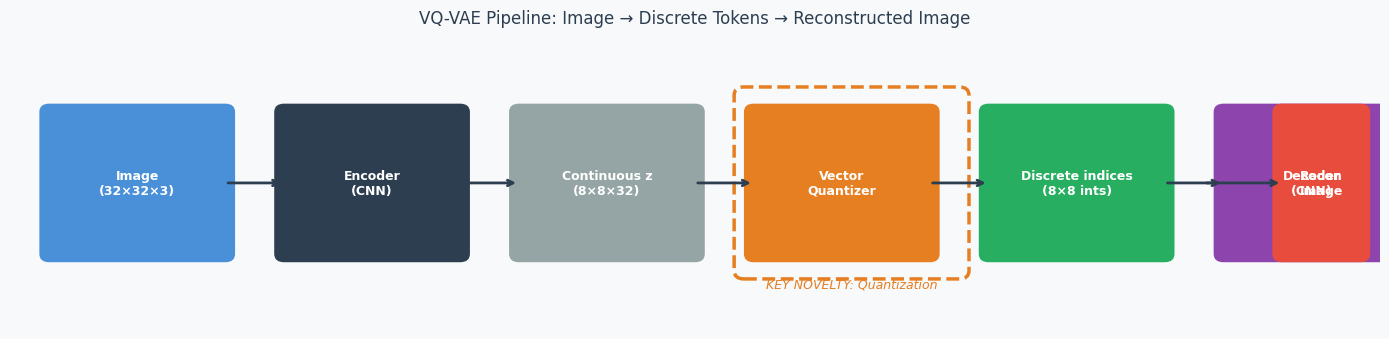

In [2]:
def draw_vqvae_pipeline():
    fig, ax = plt.subplots(figsize=(14, 3.5))
    fig.patch.set_facecolor(PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 3.5)
    ax.axis('off')

    boxes = [
        (0.4, 'Image\n(32×32×3)', PAL['blue'],    'white'),
        (2.8, 'Encoder\n(CNN)', PAL['dark'],       'white'),
        (5.2, 'Continuous z\n(8×8×32)', PAL['grey'], 'white'),
        (7.6, 'Vector\nQuantizer', PAL['orange'],  'white'),
        (10.0,'Discrete indices\n(8×8 ints)', PAL['green'], 'white'),
        (12.4,'Decoder\n(CNN)', PAL['purple'],     'white'),
    ]

    for x, label, fc, tc in boxes:
        rect = patches.FancyBboxPatch((x, 0.9), 1.8, 1.7,
            boxstyle='round,pad=0.1', facecolor=fc, edgecolor='none', zorder=2)
        ax.add_patch(rect)
        ax.text(x + 0.9, 1.75, label, ha='center', va='center',
                color=tc, fontsize=9, fontweight='bold', zorder=3)

    # Arrows
    arrow_xs = [2.2, 4.6, 7.0, 9.4, 11.8]
    for x in arrow_xs:
        ax.annotate('', xy=(x+0.6, 1.75), xytext=(x, 1.75),
            arrowprops=dict(arrowstyle='->', color=PAL['dark'], lw=2))

    # Reconstructed image box (after decoder)
    rect = patches.FancyBboxPatch((13.0, 0.9), 0.8, 1.7,
        boxstyle='round,pad=0.1', facecolor=PAL['red'], edgecolor='none', zorder=2)
    ax.add_patch(rect)
    ax.text(13.4, 1.75, 'Recon\nImage', ha='center', va='center',
            color='white', fontsize=9, fontweight='bold', zorder=3)
    ax.annotate('', xy=(13.0, 1.75), xytext=(12.2, 1.75),
        arrowprops=dict(arrowstyle='->', color=PAL['dark'], lw=2))

    # Highlight VQ box
    highlight = patches.FancyBboxPatch((7.5, 0.7), 2.2, 2.1,
        boxstyle='round,pad=0.1', facecolor='none',
        edgecolor=PAL['orange'], linewidth=2.5, linestyle='--', zorder=1)
    ax.add_patch(highlight)
    ax.text(8.6, 0.5, 'KEY NOVELTY: Quantization', ha='center',
            color=PAL['orange'], fontsize=9, style='italic')

    ax.set_title('VQ-VAE Pipeline: Image → Discrete Tokens → Reconstructed Image',
                 fontsize=12, color=PAL['dark'], pad=10)
    plt.tight_layout()
    plt.show()

draw_vqvae_pipeline()

**What we just saw:** the full VQ-VAE pipeline.  The key novelty (highlighted in orange)
is the **Vector Quantizer** step that converts a continuous 8×8×32 feature map into a
sequence of 64 integers from a codebook of size 64.  After training, those 64 integers
*completely* describe the image content — feed them to a GPT model and you have
**discrete image generation**.

---
## Problem 2 — How do we map continuous features to a finite codebook?

The encoder produces a continuous latent vector **z** for each spatial position.
We need to replace it with one of **K discrete codebook entries** e₀, e₁, …, e_{K-1}.

**Algorithm (nearest-neighbor lookup):**
1. Compute distances: `d_k = ||z - e_k||²` for all k
2. Pick the winner: `k* = argmin_k d_k`
3. Replace z with: `z_q = e_{k*}`

The result is **discrete** (an index k*) but the *value* z_q is still a continuous vector
that the decoder can process.

**Problem:** `argmin` is not differentiable → we can't backpropagate through it.
We'll solve this with the straight-through estimator in Problem 3.

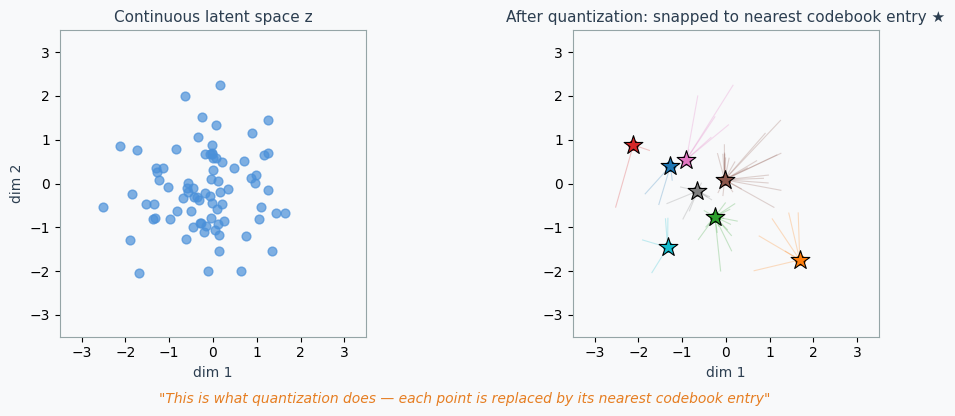

In [3]:
def draw_codebook_intuition(n_points=80, n_codes=8, seed=7):
    rng = np.random.default_rng(seed)
    points = rng.standard_normal((n_points, 2))
    codebook = rng.standard_normal((n_codes, 2)) * 1.2

    # Assign each point to nearest codebook entry
    dists = np.sum((points[:, None, :] - codebook[None, :, :])**2, axis=-1)
    assignments = np.argmin(dists, axis=1)

    colors = plt.cm.tab10(np.linspace(0, 0.9, n_codes))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.patch.set_facecolor(PAL['bg'])
    for ax in axes:
        ax.set_facecolor(PAL['bg'])
        ax.set_xlim(-3.5, 3.5)
        ax.set_ylim(-3.5, 3.5)
        ax.set_aspect('equal')
        for spine in ax.spines.values():
            spine.set_edgecolor(PAL['grey'])

    # Left: continuous latent space
    axes[0].scatter(points[:, 0], points[:, 1],
                    c=PAL['blue'], s=40, alpha=0.7, zorder=2)
    axes[0].set_title('Continuous latent space z', color=PAL['dark'], fontsize=11)
    axes[0].set_xlabel('dim 1', color=PAL['dark'])
    axes[0].set_ylabel('dim 2', color=PAL['dark'])

    # Right: quantized — each point snapped to nearest codebook entry
    for k in range(n_codes):
        mask = assignments == k
        if mask.sum() == 0:
            continue
        # Snap points to codebook entry
        snapped = np.tile(codebook[k], (mask.sum(), 1))
        # Draw lines from original to snapped
        for orig in points[mask]:
            axes[1].plot([orig[0], codebook[k, 0]],
                         [orig[1], codebook[k, 1]],
                         color=colors[k], alpha=0.25, lw=0.8, zorder=1)
        axes[1].scatter(snapped[:, 0], snapped[:, 1],
                        c=[colors[k]], s=40, alpha=0.8, zorder=3)
        axes[1].scatter(codebook[k, 0], codebook[k, 1],
                        c=[colors[k]], s=200, marker='*', edgecolors='black',
                        linewidths=0.8, zorder=4)

    axes[1].set_title('After quantization: snapped to nearest codebook entry ★',
                      color=PAL['dark'], fontsize=11)
    axes[1].set_xlabel('dim 1', color=PAL['dark'])

    fig.text(0.5, -0.02,
             '"This is what quantization does — each point is replaced by its nearest codebook entry"',
             ha='center', color=PAL['orange'], fontsize=10, style='italic')
    plt.tight_layout()
    plt.show()

draw_codebook_intuition()

**What we just saw:** on the left, continuous latent points scattered freely in 2D.
On the right, every point has been *snapped* to its nearest codebook entry (★ stars).
The lines show how far each point moved — this is the **quantization error** that
the model learns to minimize.  In practice the encoder learns to cluster its outputs
near codebook entries so the error stays small.

---
## Problem 3 — The straight-through estimator

`argmin` has zero gradient almost everywhere — backpropagation through it gives
the encoder no useful signal.

**Straight-through trick (Hinton 2012, van den Oord et al. 2017):**
- **Forward pass**: use the quantized value z_q (discrete lookup result)
- **Backward pass**: pretend we never quantized — copy gradients straight through

In PyTorch: `z_q = z + (quantized - z).detach()`

This means `dL/dz = dL/dz_q` (the `.detach()` blocks gradient flow through `quantized - z`,
so only `z` receives gradients, carrying through the decoder's signal).

**VQ-VAE loss has three terms:**
| Term | Formula | Purpose |
|------|---------|---------|
| Reconstruction | MSE(recon, x) | Make the decoder output look like input |
| Embedding (codebook) | MSE(sg[z], e) | Move codebook entries toward encoder outputs |
| Commitment | β · MSE(z, sg[e]) | Keep encoder from wandering away from codebook |

where sg[·] = stop-gradient = `.detach()` in PyTorch.

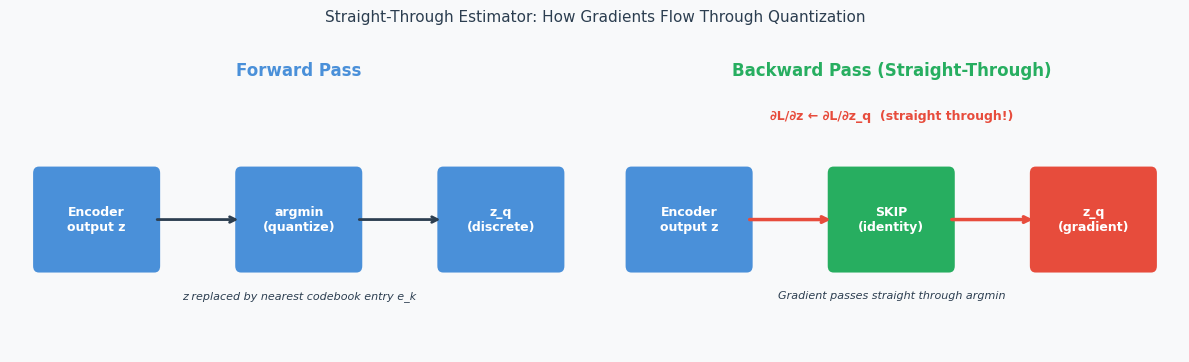

In [4]:
def draw_straight_through():
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    fig.patch.set_facecolor(PAL['bg'])

    for ax in axes:
        ax.set_facecolor(PAL['bg'])
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 4)
        ax.axis('off')

    # ── Forward pass ────────────────────────────────────────────────────────
    ax = axes[0]
    ax.set_title('Forward Pass', color=PAL['blue'], fontsize=12, fontweight='bold', pad=8)

    fwd_boxes = [(0.5, 'Encoder\noutput z'), (4.0, 'argmin\n(quantize)'), (7.5, 'z_q\n(discrete)')]
    for x, label in fwd_boxes:
        fc = PAL['blue'] if 'z' in label else PAL['orange']
        rect = patches.FancyBboxPatch((x, 1.3), 2.0, 1.4,
            boxstyle='round,pad=0.1', facecolor=fc, edgecolor='none')
        ax.add_patch(rect)
        ax.text(x + 1.0, 2.0, label, ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

    ax.annotate('', xy=(4.0, 2.0), xytext=(2.5, 2.0),
        arrowprops=dict(arrowstyle='->', color=PAL['dark'], lw=2))
    ax.annotate('', xy=(7.5, 2.0), xytext=(6.0, 2.0),
        arrowprops=dict(arrowstyle='->', color=PAL['dark'], lw=2))
    ax.text(5.0, 0.8, 'z replaced by nearest codebook entry e_k',
            ha='center', color=PAL['dark'], fontsize=8, style='italic')

    # ── Backward pass ───────────────────────────────────────────────────────
    ax = axes[1]
    ax.set_title('Backward Pass (Straight-Through)', color=PAL['green'], fontsize=12,
                 fontweight='bold', pad=8)

    bwd_boxes = [(0.5, 'Encoder\noutput z'), (4.0, 'SKIP\n(identity)'), (7.5, 'z_q\n(gradient)')]
    for x, label in bwd_boxes:
        if 'SKIP' in label:
            fc = PAL['green']
        elif 'z_q' in label:
            fc = PAL['red']
        else:
            fc = PAL['blue']
        rect = patches.FancyBboxPatch((x, 1.3), 2.0, 1.4,
            boxstyle='round,pad=0.1', facecolor=fc, edgecolor='none')
        ax.add_patch(rect)
        ax.text(x + 1.0, 2.0, label, ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

    # Gradient flows backward (right to left)
    ax.annotate('', xy=(2.5, 2.0), xytext=(4.0, 2.0),
        arrowprops=dict(arrowstyle='<-', color=PAL['red'], lw=2.5))
    ax.annotate('', xy=(6.0, 2.0), xytext=(7.5, 2.0),
        arrowprops=dict(arrowstyle='<-', color=PAL['red'], lw=2.5))

    ax.text(5.0, 3.5, '∂L/∂z ← ∂L/∂z_q  (straight through!)',
            ha='center', color=PAL['red'], fontsize=9, fontweight='bold')
    ax.text(5.0, 0.8, 'Gradient passes straight through argmin',
            ha='center', color=PAL['dark'], fontsize=8, style='italic')

    plt.suptitle('Straight-Through Estimator: How Gradients Flow Through Quantization',
                 color=PAL['dark'], fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

draw_straight_through()

**What we just saw:** in the **forward pass** (left), z is replaced by the nearest
codebook entry via `argmin`.  In the **backward pass** (right), gradients skip over
the quantization step entirely — as if it were an identity function.

**Two-sentence intuition before the maths:** In the *forward pass*, the decoder receives the quantized code z_q — the result of the hard discrete lookup. In the *backward pass*, we pretend quantisation never happened: the decoder's gradient flows straight through to the encoder output z, as if z_q *were* z. The effect: (1) the encoder is pushed to bring its outputs closer to the codebook entry that was selected, and (2) the decoder is trained to work well with that entry. Neither sees a dead gradient.

In PyTorch this is implemented with just one line:
```python
z_q = z + (quantized - z).detach()
```
The `.detach()` stops `quantized - z` from receiving gradients, so `dL/dz = dL/dz_q`.

In [5]:
class VectorQuantizer(nn.Module):
    """The core VQ-VAE quantization module.

    Args:
        n_embeddings:    number of codebook entries (vocabulary size)
        embedding_dim:   dimension of each codebook vector
        commitment_cost: weight β for the commitment loss term
    """
    def __init__(self, n_embeddings: int, embedding_dim: int,
                 commitment_cost: float = 0.25):
        super().__init__()
        self.n_embeddings    = n_embeddings
        self.embedding_dim   = embedding_dim
        self.commitment_cost = commitment_cost
        # Codebook: (n_embeddings, embedding_dim)
        self.embedding = nn.Embedding(n_embeddings, embedding_dim)
        nn.init.uniform_(self.embedding.weight,
                         -1 / n_embeddings, 1 / n_embeddings)

    def forward(self, z):
        """
        Args:
            z: (B, H, W, D) — encoder output, channel-last format
        Returns:
            quantized_st: (B, H, W, D) straight-through quantized tensor
            loss:         scalar VQ loss (embedding + commitment)
            indices:      (B, H*W) integer codebook indices
        """
        B, H, W, D = z.shape
        # Flatten spatial dims → (B*H*W, D)
        z_flat = z.reshape(-1, D)

        # 1. Compute squared distances: ||z - e_k||² for all k
        #    = ||z||² - 2·z·eᵀ + ||e||²
        z_sq   = (z_flat ** 2).sum(dim=1, keepdim=True)           # (N, 1)
        e_sq   = (self.embedding.weight ** 2).sum(dim=1)          # (K,)
        dot    = z_flat @ self.embedding.weight.t()                # (N, K)
        dists  = z_sq + e_sq - 2 * dot                            # (N, K)

        # 2. Nearest-neighbor lookup
        indices_flat = dists.argmin(dim=1)                         # (N,)

        # 3. Look up quantized vectors
        quantized_flat = self.embedding(indices_flat)              # (N, D)
        quantized      = quantized_flat.reshape(B, H, W, D)

        # 4. Straight-through estimator
        quantized_st = z + (quantized - z).detach()

        # 5. Losses
        embedding_loss  = F.mse_loss(quantized, z.detach())       # codebook update
        commitment_loss = F.mse_loss(quantized.detach(), z)       # encoder update
        loss = embedding_loss + self.commitment_cost * commitment_loss

        indices = indices_flat.reshape(B, H * W)
        return quantized_st, loss, indices

print("VectorQuantizer defined ✓")

VectorQuantizer defined ✓


In [6]:
class Encoder(nn.Module):
    """CNN encoder: image (B, C, 32, 32) → latent (B, embedding_dim, 8, 8).

    Two stride-2 convolutions halve spatial size twice: 32→16→8.
    """
    def __init__(self, in_channels: int, embedding_dim: int,
                 hidden_channels: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            # 32×32 → 16×16
            nn.Conv2d(in_channels, hidden_channels, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # 16×16 → 8×8
            nn.Conv2d(hidden_channels, hidden_channels * 2, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # Project to embedding_dim (no spatial change)
            nn.Conv2d(hidden_channels * 2, embedding_dim, 1),
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    """CNN decoder: latent (B, embedding_dim, 8, 8) → image (B, C, 32, 32).

    Mirror of Encoder using ConvTranspose2d for upsampling.
    """
    def __init__(self, embedding_dim: int, out_channels: int,
                 hidden_channels: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            # Expand from embedding_dim
            nn.Conv2d(embedding_dim, hidden_channels * 2, 1),
            nn.ReLU(inplace=True),
            # 8×8 → 16×16
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels,
                               4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # 16×16 → 32×32
            nn.ConvTranspose2d(hidden_channels, out_channels,
                               4, stride=2, padding=1),
        )

    def forward(self, z_q):
        return self.net(z_q)


print("Encoder & Decoder defined ✓")

Encoder & Decoder defined ✓


In [7]:
class VQVAE(nn.Module):
    """Vector Quantized Variational Autoencoder.

    Combines Encoder → VectorQuantizer → Decoder into one module.

    Args:
        in_channels:      number of image channels (e.g. 3 for RGB)
        embedding_dim:    codebook vector dimension
        n_embeddings:     codebook size (vocabulary)
        hidden_channels:  intermediate CNN channels
        commitment_cost:  weight for commitment loss
    """
    def __init__(self, in_channels: int, embedding_dim: int,
                 n_embeddings: int, hidden_channels: int = 32,
                 commitment_cost: float = 0.25):
        super().__init__()
        self.encoder   = Encoder(in_channels, embedding_dim, hidden_channels)
        self.quantizer = VectorQuantizer(n_embeddings, embedding_dim, commitment_cost)
        self.decoder   = Decoder(embedding_dim, in_channels, hidden_channels)

    def forward(self, x):
        """Full forward pass.
        Returns: (recon, total_loss, indices, recon_loss_val, vq_loss_val)
        """
        z              = self.encoder(x)                          # (B, D, 8, 8)
        z_q, vq_loss, indices = self.quantizer(z.permute(0,2,3,1))  # → (B,H,W,D)
        recon          = self.decoder(z_q.permute(0,3,1,2))          # → (B,D,H,W)
        recon_loss     = F.mse_loss(recon, x)
        loss           = recon_loss + vq_loss
        return recon, loss, indices, recon_loss.item(), vq_loss.item()

    def encode_to_indices(self, x):
        """Image → discrete token sequence.

        Returns indices of shape (B, H*W) — integer codebook indices.
        This is the bridge to downstream language model generation.
        """
        z = self.encoder(x)
        _, _, indices = self.quantizer(z.permute(0,2,3,1))
        return indices   # (B, 64) for 8×8 spatial, int64

    def decode_from_indices(self, indices, spatial_size=(8, 8)):
        """Discrete token sequence → image.

        Args:
            indices:      (B, H*W) integer codebook indices
            spatial_size: (H, W) of the latent feature map
        """
        H, W = spatial_size
        B    = indices.shape[0]
        # Look up embedding vectors
        z_q = self.quantizer.embedding(indices)      # (B, H*W, D)
        z_q = z_q.reshape(B, H, W, -1)              # (B, H, W, D)
        z_q = z_q.permute(0, 3, 1, 2)               # (B, D, H, W)
        return self.decoder(z_q)


# ── Quick sanity check ────────────────────────────────────────────────────────
_model = VQVAE(in_channels=3, embedding_dim=32, n_embeddings=64, hidden_channels=32)
_x     = torch.randn(2, 3, 32, 32)
_recon, _loss, _idx, _rl, _vl = _model(_x)
print(f"Input shape:       {_x.shape}")
print(f"Recon shape:       {_recon.shape}")
print(f"Index shape:       {_idx.shape}  (B × H*W)")
print(f"Recon loss:        {_rl:.4f}")
print(f"VQ loss:           {_vl:.4f}")
print(f"Total loss:        {_loss.item():.4f}")
print("VQVAE sanity check ✓")

Input shape:       torch.Size([2, 3, 32, 32])
Recon shape:       torch.Size([2, 3, 32, 32])
Index shape:       torch.Size([2, 64])  (B × H*W)
Recon loss:        1.0030
VQ loss:           0.0093
Total loss:        1.0124
VQVAE sanity check ✓


In [8]:
class SyntheticImageDataset(Dataset):
    """Four-class synthetic image dataset for VQ-VAE training.

    Classes (all 32×32 RGB, values in [0, 1]):
        0: solid red patch      1: solid blue patch
        2: vertical stripes     3: horizontal stripes
    """
    CLASS_NAMES = ['Solid Red', 'Solid Blue', 'V-Stripes', 'H-Stripes']

    def __init__(self, n_per_class: int = 250, img_size: int = 32, seed: int = 42):
        rng = np.random.default_rng(seed)
        self.data, self.labels = [], []
        for label in range(4):
            for _ in range(n_per_class):
                img = np.zeros((3, img_size, img_size), dtype=np.float32)
                noise = rng.standard_normal((3, img_size, img_size)).astype(np.float32) * 0.05

                if label == 0:   # Solid Red
                    img[0] = 0.85
                    img[1] = 0.10
                    img[2] = 0.10
                elif label == 1: # Solid Blue
                    img[0] = 0.10
                    img[1] = 0.10
                    img[2] = 0.85
                elif label == 2: # Vertical stripes
                    for col in range(img_size):
                        v = 0.9 if (col // 4) % 2 == 0 else 0.1
                        img[:, :, col] = v
                else:            # Horizontal stripes
                    for row in range(img_size):
                        v = 0.9 if (row // 4) % 2 == 0 else 0.1
                        img[:, row, :] = v

                img = np.clip(img + noise, 0, 1)
                self.data.append(torch.from_numpy(img))
                self.labels.append(label)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]


dataset    = SyntheticImageDataset(n_per_class=250)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0)
print(f"Dataset size: {len(dataset)} images ({len(dataset)//4} per class)")
print(f"Image shape: {dataset[0][0].shape}")

Dataset size: 1000 images (250 per class)
Image shape: torch.Size([3, 32, 32])


---
## Problem 4 — Training the VQ-VAE and connecting to downstream generation

Now we train the VQ-VAE end-to-end.  The three-term loss drives:
1. **Reconstruction loss** → decoder learns to invert the encoder
2. **Embedding loss** → codebook entries move toward encoder outputs
3. **Commitment loss** → encoder outputs stay near their assigned codebook entries

After training, we can:
- **Reconstruct**: encode any image → indices → decode → image
- **Generate**: feed indices to GPT → new indices → decode → new image

This is exactly how **DALL-E 1** (2021) worked — VQ-VAE tokenizer + GPT generator.

In [9]:
def train_vqvae(model, dataloader, n_epochs=80, lr=2e-3, device=DEVICE):
    """Train VQ-VAE and return per-epoch loss history."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    recon_history, vq_history = [], []

    for epoch in range(n_epochs):
        model.train()
        total_recon, total_vq, n_batches = 0.0, 0.0, 0

        for imgs, _ in dataloader:
            imgs = imgs.to(device)
            optimizer.zero_grad()
            _, loss, _, rl, vl = model(imgs)
            loss.backward()
            optimizer.step()

            total_recon += rl
            total_vq    += vl
            n_batches   += 1

        avg_recon = total_recon / n_batches
        avg_vq    = total_vq    / n_batches
        recon_history.append(avg_recon)
        vq_history.append(avg_vq)

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} | "
                  f"recon: {avg_recon:.4f} | vq: {avg_vq:.4f}")

    return recon_history, vq_history


model = VQVAE(in_channels=3, embedding_dim=32, n_embeddings=64, hidden_channels=32)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print("Starting training...")
recon_hist, vq_hist = train_vqvae(model, dataloader, n_epochs=80)
print("Training complete ✓")

Model parameters: 74,979
Starting training...


Epoch  20/80 | recon: 0.0042 | vq: 0.0087


Epoch  40/80 | recon: 0.0026 | vq: 0.0004


Epoch  60/80 | recon: 0.0025 | vq: 0.0002


Epoch  80/80 | recon: 0.0024 | vq: 0.0001
Training complete ✓


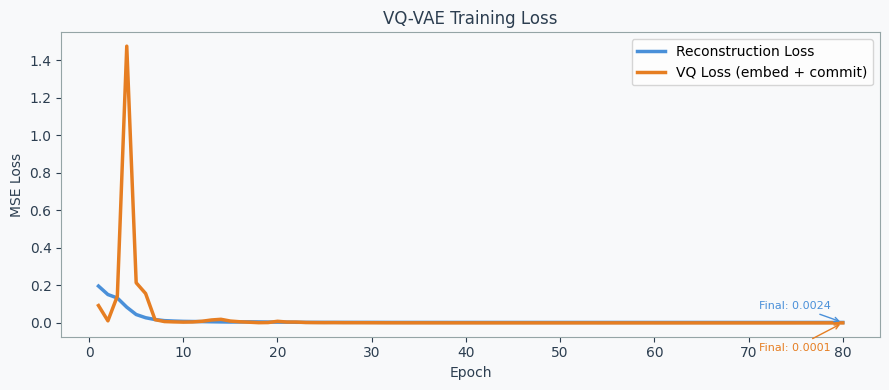

In [10]:
def plot_training_losses(recon_hist, vq_hist):
    epochs = range(1, len(recon_hist) + 1)
    fig, ax = plt.subplots(figsize=(9, 4))
    fig.patch.set_facecolor(PAL['bg'])
    ax.set_facecolor(PAL['bg'])

    ax.plot(epochs, recon_hist, color=PAL['blue'],   lw=2.5, label='Reconstruction Loss')
    ax.plot(epochs, vq_hist,    color=PAL['orange'],  lw=2.5, label='VQ Loss (embed + commit)')

    ax.set_xlabel('Epoch', color=PAL['dark'])
    ax.set_ylabel('MSE Loss', color=PAL['dark'])
    ax.set_title('VQ-VAE Training Loss', color=PAL['dark'], fontsize=12)
    ax.legend(framealpha=0.8)
    ax.tick_params(colors=PAL['dark'])
    for spine in ax.spines.values():
        spine.set_edgecolor(PAL['grey'])

    # Annotate final values
    ax.annotate(f'Final: {recon_hist[-1]:.4f}',
                xy=(len(epochs), recon_hist[-1]),
                xytext=(-60, 10), textcoords='offset points',
                color=PAL['blue'], fontsize=8,
                arrowprops=dict(arrowstyle='->', color=PAL['blue'], lw=1))
    ax.annotate(f'Final: {vq_hist[-1]:.4f}',
                xy=(len(epochs), vq_hist[-1]),
                xytext=(-60, -20), textcoords='offset points',
                color=PAL['orange'], fontsize=8,
                arrowprops=dict(arrowstyle='->', color=PAL['orange'], lw=1))

    plt.tight_layout()
    plt.show()

plot_training_losses(recon_hist, vq_hist)

**What we just saw:** two loss curves over 80 epochs.
- **Reconstruction loss** (blue) measures how well the decoder recovers the original image
  from quantized latents.  It should drop steadily as the encoder/decoder learn.
- **VQ loss** (orange) measures how well the codebook entries match the encoder outputs
  (embedding loss) and how close the encoder stays to its assigned entries (commitment loss).

A well-trained VQ-VAE has low reconstruction loss — the quantization bottleneck
doesn't destroy too much information.

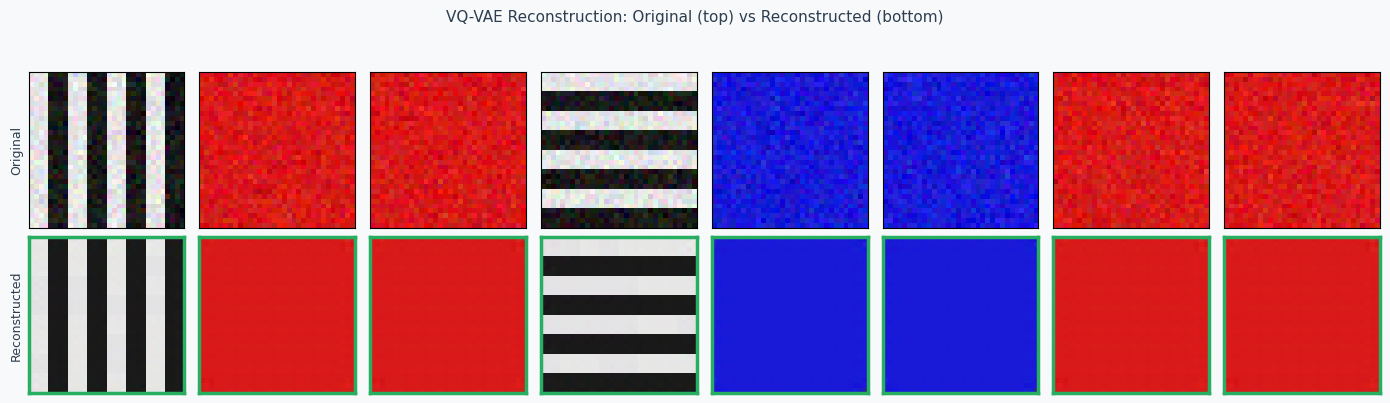

In [11]:
def show_reconstructions(model, dataset, n=8, device=DEVICE):
    """Show original vs reconstructed images side by side."""
    model.eval()
    indices = random.sample(range(len(dataset)), n)
    imgs    = torch.stack([dataset[i][0] for i in indices]).to(device)

    with torch.no_grad():
        recons, _, _, _, _ = model(imgs)

    recons = recons.cpu().clamp(0, 1)
    imgs   = imgs.cpu()

    fig, axes = plt.subplots(2, n, figsize=(14, 4))
    fig.patch.set_facecolor(PAL['bg'])

    row_labels = ['Original', 'Reconstructed']
    for row, (row_imgs, label) in enumerate(zip([imgs, recons], row_labels)):
        for col in range(n):
            ax = axes[row, col]
            img_np = row_imgs[col].permute(1, 2, 0).numpy()
            ax.imshow(img_np)
            ax.set_xticks([])
            ax.set_yticks([])

            # Green border for reconstructions
            if row == 1:
                for spine in ax.spines.values():
                    spine.set_edgecolor(PAL['green'])
                    spine.set_linewidth(2.5)

            if col == 0:
                ax.set_ylabel(label, color=PAL['dark'], fontsize=9)

    fig.suptitle('VQ-VAE Reconstruction: Original (top) vs Reconstructed (bottom)',
                 color=PAL['dark'], fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

show_reconstructions(model, dataset)

**What we just saw:** 8 original images (top row) and their reconstructions (bottom row,
green border).  Despite compressing each 32×32×3 image into just 64 integers (8×8 spatial
positions × log₂(64) = 6 bits each), the VQ-VAE recovers the main structure faithfully.

The remaining blurriness or noise is the **quantization error** — information lost
when snapping continuous latents to the nearest codebook entry.

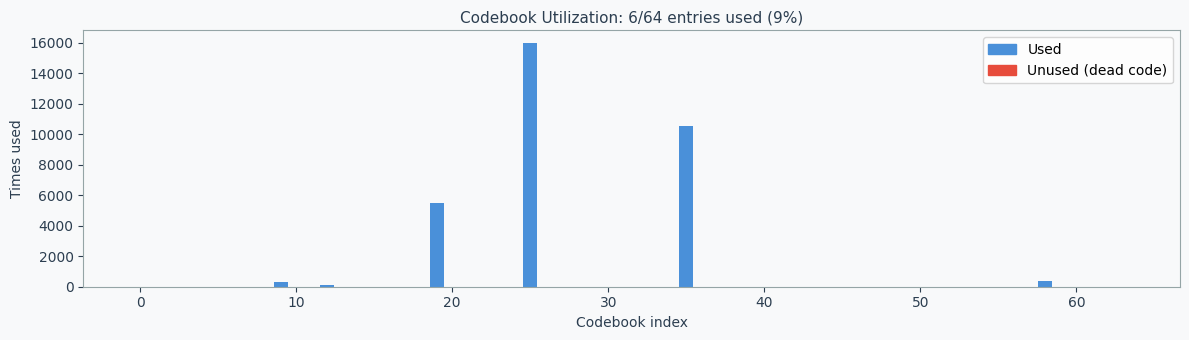

Codebook utilization: 6/64 = 9%


In [12]:
def show_codebook_usage(model, dataset, device=DEVICE, sample_n=500):
    """Bar chart of how many times each codebook entry is used."""
    model.eval()
    counts = torch.zeros(model.quantizer.n_embeddings, dtype=torch.long)

    loader = DataLoader(dataset, batch_size=64, shuffle=False)
    with torch.no_grad():
        n_seen = 0
        for imgs, _ in loader:
            if n_seen >= sample_n:
                break
            imgs = imgs.to(device)
            idxs = model.encode_to_indices(imgs)   # (B, 64)
            for k in idxs.flatten().cpu():
                counts[k] += 1
            n_seen += imgs.shape[0]

    counts_np = counts.numpy()
    n_used    = (counts_np > 0).sum()

    fig, ax = plt.subplots(figsize=(12, 3.5))
    fig.patch.set_facecolor(PAL['bg'])
    ax.set_facecolor(PAL['bg'])

    xs     = np.arange(model.quantizer.n_embeddings)
    colors = [PAL['blue'] if c > 0 else PAL['red'] for c in counts_np]
    ax.bar(xs, counts_np, color=colors, edgecolor='none', width=0.9)

    ax.set_xlabel('Codebook index', color=PAL['dark'])
    ax.set_ylabel('Times used', color=PAL['dark'])
    ax.set_title(
        f'Codebook Utilization: {n_used}/{model.quantizer.n_embeddings} entries used '
        f'({100*n_used/model.quantizer.n_embeddings:.0f}%)',
        color=PAL['dark'], fontsize=11)
    ax.tick_params(colors=PAL['dark'])
    for spine in ax.spines.values():
        spine.set_edgecolor(PAL['grey'])

    import matplotlib.patches as mpatches
    legend = [mpatches.Patch(color=PAL['blue'], label='Used'),
              mpatches.Patch(color=PAL['red'],  label='Unused (dead code)')]
    ax.legend(handles=legend, framealpha=0.8)

    plt.tight_layout()
    plt.show()
    print(f"Codebook utilization: {n_used}/{model.quantizer.n_embeddings} = "
          f"{100*n_used/model.quantizer.n_embeddings:.0f}%")

show_codebook_usage(model, dataset)

**What we just saw:** how often each of the 64 codebook entries is used across 500 images.

- **Blue bars**: entries that are actively used (good)
- **Red bars**: unused entries — "dead codes" that the encoder never selects

High utilization means the codebook is efficiently describing the image distribution.
If many entries are unused, the effective vocabulary is smaller than K=64.

**Real-world fix:** techniques like codebook reset (re-initialise dead codes to random
encoder outputs) dramatically improve utilization — used in DALL-E 1, VQ-GAN, etc.

/tmp/ipykernel_19239/1246926059.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab20', n_codes)


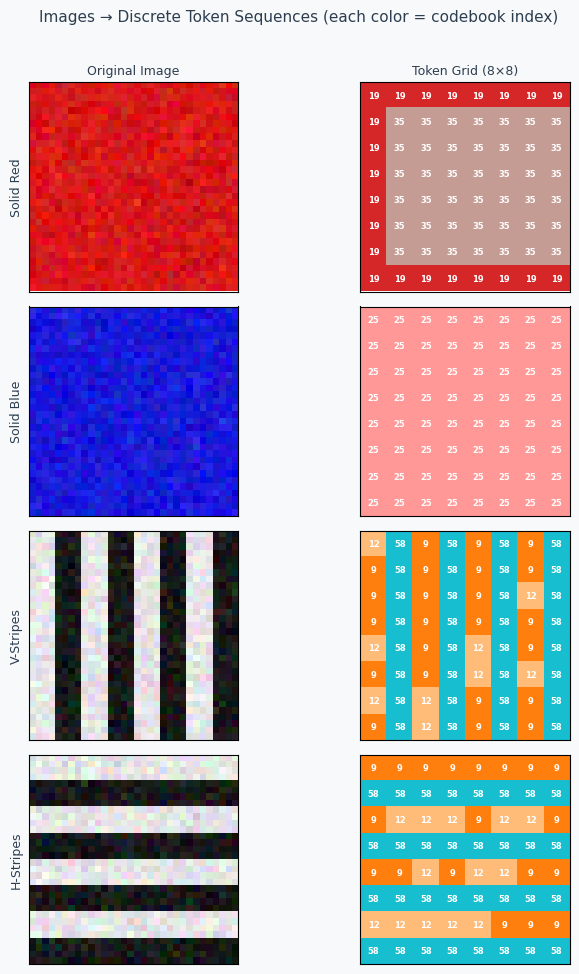

In [13]:
def show_token_sequences(model, dataset, n_images=4, device=DEVICE):
    """Show images alongside their discrete token grids."""
    # Pick one image per class
    class_indices = []
    for cls in range(4):
        for i in range(len(dataset)):
            if dataset[i][1] == cls:
                class_indices.append(i)
                break

    imgs = torch.stack([dataset[i][0] for i in class_indices[:n_images]]).to(device)
    model.eval()
    with torch.no_grad():
        indices = model.encode_to_indices(imgs)   # (n_images, 64)

    indices_np = indices.cpu().numpy()            # (n_images, 64)
    imgs_cpu   = imgs.cpu()

    # Build a colormap: each codebook index gets a unique color
    n_codes = model.quantizer.n_embeddings
    cmap    = plt.cm.get_cmap('tab20', n_codes)

    fig, axes = plt.subplots(n_images, 2, figsize=(8, n_images * 2.4))
    fig.patch.set_facecolor(PAL['bg'])

    for row in range(n_images):
        # Left: original image
        ax_img = axes[row, 0]
        ax_img.imshow(imgs_cpu[row].permute(1, 2, 0).numpy())
        ax_img.set_xticks([])
        ax_img.set_yticks([])
        ax_img.set_ylabel(dataset.CLASS_NAMES[dataset[class_indices[row]][1]],
                          color=PAL['dark'], fontsize=9)

        # Right: token grid (8×8)
        ax_tok = axes[row, 1]
        token_grid = indices_np[row].reshape(8, 8)
        ax_tok.imshow(token_grid, cmap=cmap, vmin=0, vmax=n_codes - 1,
                      interpolation='nearest')
        ax_tok.set_xticks([])
        ax_tok.set_yticks([])
        if row == 0:
            ax_tok.set_title('Token Grid (8×8)', color=PAL['dark'], fontsize=9)
            axes[row, 0].set_title('Original Image', color=PAL['dark'], fontsize=9)

        # Annotate token grid with index values
        for r in range(8):
            for c in range(8):
                ax_tok.text(c, r, str(token_grid[r, c]),
                            ha='center', va='center',
                            color='white', fontsize=6, fontweight='bold')

    fig.suptitle('Images → Discrete Token Sequences (each color = codebook index)',
                 color=PAL['dark'], fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

show_token_sequences(model, dataset)

**What we just saw:** each image (left column) represented as a **8×8 grid of integers**
(right column — colors map to codebook indices, numbers inside each cell show the index).

Key observations:
- **Similar images → similar token patterns**: the solid-red and solid-blue images use
  uniform grids because they have homogeneous content.
- **Structured images → structured tokens**: striped images show repeating token patterns.
- These 64-integer sequences are now ready for an autoregressive GPT to model!

This is the exact representation DALL-E 1 used: a VQ-VAE reduced every 256×256 image
to a 32×32 = 1024-token sequence, and GPT-3 scale models learned to predict those.

Round-trip: image → indices → image
  Input:   torch.Size([4, 3, 32, 32])
  Indices: torch.Size([4, 64])  dtype=torch.int64  values in [0, 58]
  Output:  torch.Size([4, 3, 32, 32])
  Round-trip MSE: 0.00247


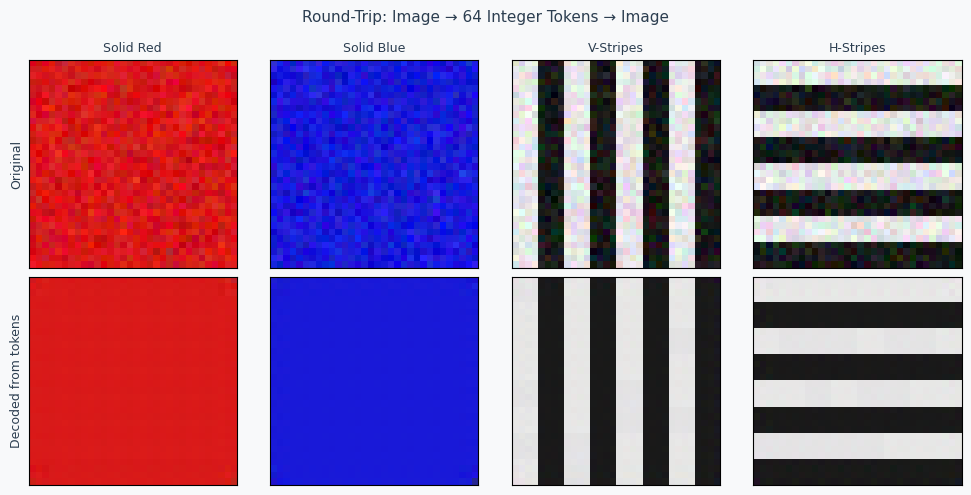

In [14]:
# ── Round-trip demo: image → indices → image ─────────────────────────────────
def round_trip_demo(model, dataset, device=DEVICE):
    """Demonstrate the full image tokenization pipeline."""
    model.eval()
    # Pick 4 images (one per class)
    class_indices = []
    for cls in range(4):
        for i in range(len(dataset)):
            if dataset[i][1] == cls:
                class_indices.append(i)
                break

    imgs = torch.stack([dataset[i][0] for i in class_indices]).to(device)

    with torch.no_grad():
        # Step 1: encode to discrete indices
        indices = model.encode_to_indices(imgs)   # (4, 64)
        # Step 2: decode back from indices
        recons  = model.decode_from_indices(indices, spatial_size=(8, 8))
        recons  = recons.clamp(0, 1).cpu()

    print("Round-trip: image → indices → image")
    print(f"  Input:   {imgs.shape}")
    print(f"  Indices: {indices.shape}  dtype={indices.dtype}  values in [0, {indices.max().item()}]")
    print(f"  Output:  {recons.shape}")

    pixel_mse = F.mse_loss(recons, imgs.cpu()).item()
    print(f"  Round-trip MSE: {pixel_mse:.5f}")

    fig, axes = plt.subplots(2, 4, figsize=(10, 5))
    fig.patch.set_facecolor(PAL['bg'])
    for col in range(4):
        for row, (img_set, label) in enumerate([(imgs.cpu(), 'Original'),
                                                 (recons, 'Decoded from tokens')]):
            ax = axes[row, col]
            ax.imshow(img_set[col].permute(1,2,0).numpy())
            ax.set_xticks([])
            ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(label, color=PAL['dark'], fontsize=9)
            if row == 0:
                name = dataset.CLASS_NAMES[dataset[class_indices[col]][1]]
                ax.set_title(name, color=PAL['dark'], fontsize=9)

    fig.suptitle('Round-Trip: Image → 64 Integer Tokens → Image',
                 color=PAL['dark'], fontsize=11)
    plt.tight_layout()
    plt.show()

round_trip_demo(model, dataset)

**What we just saw:** the complete pipeline running end-to-end.
1. Each 32×32 image is encoded to **64 integer tokens** (indices into the codebook)
2. The same tokens are decoded back to a 32×32 image

The round-trip MSE measures information lost in quantization.  Lower = better.

**Connection to other architectures:**
| System | Tokenizer | Downstream model |
|--------|-----------|-----------------|
| DALL-E 1 | VQ-VAE (dVAE) | GPT-3 scale transformer |
| Chameleon | VQ-VAE | Mixed-modal transformer |
| VQ-GAN + GPT | VQ-GAN | Transformer prior |
| Latent Diffusion | VAE (no quantization) | Diffusion U-Net |

The key insight: **once you have discrete image tokens, the image generation problem
becomes a sequence modelling problem** — exactly what transformers excel at.

In [15]:
# ── Illustrate: what a "GPT for images" would consume ────────────────────────
def show_gpt_connection(model, dataset, device=DEVICE):
    """Show how VQ-VAE tokens could feed into a GPT-style model."""
    model.eval()
    # Pick one image
    img, label = dataset[0]
    img_t = img.unsqueeze(0).to(device)

    with torch.no_grad():
        indices = model.encode_to_indices(img_t)[0]   # (64,)

    print("── Discrete image tokens (ready for GPT) ──────────────────────────────")
    print(f"Image class: {dataset.CLASS_NAMES[label]}")
    print(f"Codebook vocabulary size: {model.quantizer.n_embeddings}")
    print(f"Sequence length:          {indices.shape[0]}  (8×8 spatial positions)")
    print()
    print("Token sequence (first 64 integers, like word IDs in a sentence):")
    print(indices.cpu().numpy().reshape(8, 8))
    print()
    print("In a GPT-for-images system, this sequence would be:")
    print("  • Prepended with a class token: [<RED>, 12, 7, 43, 2, ...]")
    print("  • Fed autoregressively: predict token 2 given tokens [<RED>, 12, 7]")
    print("  • At inference: sample tokens one by one, then VQ-VAE decode → image")

show_gpt_connection(model, dataset)

── Discrete image tokens (ready for GPT) ──────────────────────────────
Image class: Solid Red
Codebook vocabulary size: 64
Sequence length:          64  (8×8 spatial positions)

Token sequence (first 64 integers, like word IDs in a sentence):
[[19 19 19 19 19 19 19 19]
 [19 35 35 35 35 35 35 35]
 [19 35 35 35 35 35 35 35]
 [19 35 35 35 35 35 35 35]
 [19 35 35 35 35 35 35 35]
 [19 35 35 35 35 35 35 35]
 [19 35 35 35 35 35 35 35]
 [19 19 19 19 19 19 19 19]]

In a GPT-for-images system, this sequence would be:
  • Prepended with a class token: [<RED>, 12, 7, 43, 2, ...]
  • Fed autoregressively: predict token 2 given tokens [<RED>, 12, 7]
  • At inference: sample tokens one by one, then VQ-VAE decode → image


## Exercises

1. **Codebook collapse** — Reduce `codebook_size` from 64 to 8 and re-run training. Plot codebook utilisation (how many of the 8 codes are actually assigned) per epoch. At what size does “collapse” occur — where a few codes dominate and the rest go unused? What does reconstruction look like with only 3 active codes?

2. **Remove commitment loss** — Set `beta = 0` (the commitment loss weight) and re-run. Plot codebook utilisation over training compared to `beta=0.25`. The commitment loss is what stops the encoder features from drifting away from the codebook — show this effect empirically.

3. **VQ-VAE as a tokeniser for GPT** — After training the VQ-VAE, encode all 200 training images and collect their 64-length token index sequences. Train a small GPT (`n_layer=2, n_head=2, n_embd=64`) on these sequences (next-token prediction). Sample 5 sequences from the GPT, decode each through the VQ-VAE decoder, and display the generated images. This is exactly how DALL-E’s autoregressive image generation works.

## Scaling to Real Data

| Hyperparameter | This notebook | VQ-VAE-2 | DALL-E dVAE |
|---|---|---|---|
| `codebook_size` | 64 | 512 (×2 levels) | 8 192 |
| `embedding_dim` | 32 | 256 | 512 |
| Encoder channels | 16 | 128 | 512 |
| Token grid | 8×8 (64 tokens) | 32×32 (1 024 tokens) | 32×32 (1 024 tokens) |
| Training images | 200 synthetic | ImageNet (1.28 M) | 250 M internet images |
| Reconstruction loss | MSE | MSE + perceptual | MSE + perceptual |

**Perceptual loss** — Production VQ-VAEs add a VGG-based perceptual loss (feature-level MSE, not pixel MSE) and often a GAN discriminator loss to sharpen reconstructions. The codebook size of 8192 in DALL-E means each spatial position can encode one of 8192 visual concepts.

**To use a pre-trained VQ-GAN:**
```python
# pip install taming-transformers
from taming.models.vqgan import VQModel
vqgan = VQModel.from_pretrained("CompVis/ldm-celebahq-256")
z, _, (_, _, indices) = vqgan.encode(image_tensor)  # discrete token indices
```

## Chapter Summary

**What we built** — A Vector-Quantised Variational Autoencoder (VQ-VAE): a CNN encoder compresses a 32×32 image to an 8×8 feature grid; vector quantisation replaces each feature vector with its nearest codebook entry (using the straight-through gradient estimator); a CNN decoder reconstructs the image from the quantised codes. The discrete token sequence (64 indices from a vocabulary of 64) is the image’s “language-model-ready” representation.

**Why it matters** — Making images discrete is the prerequisite for treating image generation as sequence modelling. Once images are represented as token sequences, any language model architecture — autoregressive Transformer, BERT, or GPT — can be applied to image generation without modification. This insight powers DALL-E (8192 visual tokens via dVAE), VQ-GAN, and Chameleon.

**Connections** — VQ-VAE discretises images in the same spirit as BPE tokenisation discretises text. The discrete representation can be fed directly to the GPT from Ch03 — Exercise 3 walks through this. Ch07 (diffusion) provides an alternative continuous-space generative approach; Stable Diffusion combines both by running diffusion *inside* a VQ-VAE latent space.